In [9]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

df = pd.read_csv(r"C:\Users\Acer\Downloads\didi ppt\Customer Churn.csv")
df.head()
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


# replace blanks with 0 as tenure is zero

In [10]:
df["TotalCharges"] = df["TotalCharges"].replace(" ","0")
df["TotalCharges"] = df["TotalCharges"].astype("float")

In [11]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [ ]:
# checking null values


In [12]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [13]:
df.describe()

,SeniorCitizen,tenure,MonthlyCharges,TotalCharges
count,7043.000000,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692,2279.734304
std,0.368612,24.559481,30.090047,2266.794470
min,0.000000,0.000000,18.250000,0.000000
25%,0.000000,9.000000,35.500000,398.550000
50%,0.000000,29.000000,70.350000,1394.550000
75%,0.000000,55.000000,89.850000,3786.600000
max,1.000000,72.000000,118.750000,8684.800000


In [15]:
df.duplicated().sum()

np.int64(0)

In [ ]:
# converted 0 and 1 values of senior citizen to yes/no 

In [16]:
def conv(value):
    if value == 1:
        return "yes"
    else:   
        return "no"
df["SeniorCitizen"] = df["SeniorCitizen"].apply(conv)        

In [17]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,no,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,no,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,no,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,no,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,no,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


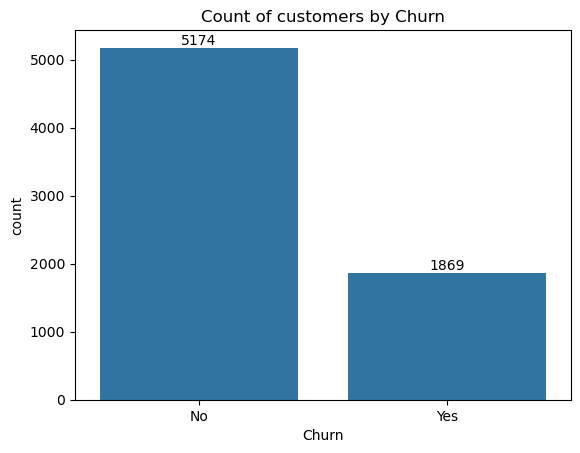

In [26]:
ax = sns.countplot(x = 'Churn',data = df)

ax.bar_label(ax.containers[0])
plt.title("Count of customers by Churn")
plt.show()

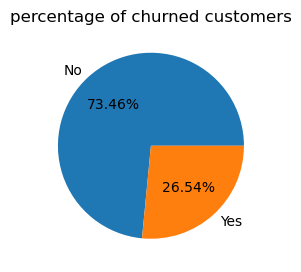

In [29]:
plt.figure(figsize = (3,4))
gb = df.groupby("Churn").agg({'Churn':'count'})
plt.pie(gb['Churn'],labels = gb.index,autopct = '%1.2f%%')
plt.title("percentage of churned customers")
plt.show()

In [ ]:
# from the given pie chart we chart we can conclude that 26.54% of customer have curned out 
# not lets explore the reason behind it 

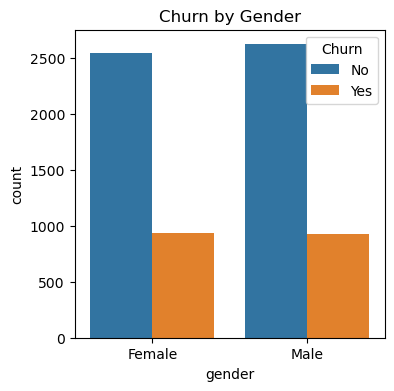

In [35]:
plt.figure(figsize = (4,4))
sns.countplot(x = 'gender',data = df,hue = "Churn")
plt.title("Churn by Gender")
plt.show()

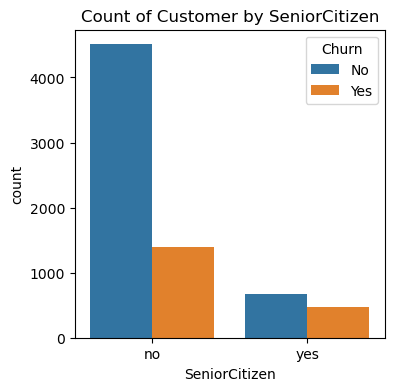

In [38]:
plt.figure(figsize = (4,4))
sns.countplot(x = 'SeniorCitizen',data = df,hue = "Churn")
plt.title("Count of Customer by SeniorCitizen")
plt.show()

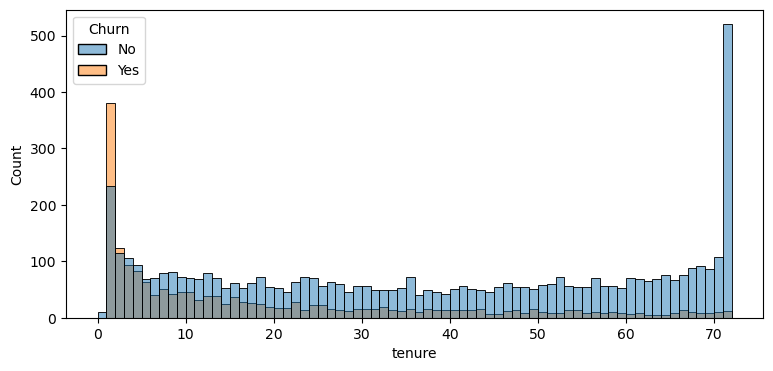

In [42]:
plt.figure(figsize = (9,4))
sns.histplot(x = "tenure",data = df,bins = 72,hue = 'Churn')
plt.show()

In [ ]:
# people who used our services for a long time have stayed and people who have used or services 

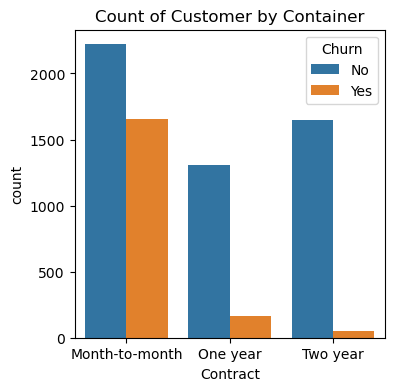

In [43]:
plt.figure(figsize = (4,4))
sns.countplot(x = 'Contract',data = df,hue = "Churn")
plt.title("Count of Customer by Container")
plt.show()

In [ ]:
# people who have month to month contract are likely to churn then from those who have 1 or 2 years or contract

In [46]:
df.columns.values

array(['customerID', 'gender', 'SeniorCitizen', 'Partner', 'Dependents',
       'tenure', 'PhoneService', 'MultipleLines', 'InternetService',
       'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
       'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract',
       'PaperlessBilling', 'PaymentMethod', 'MonthlyCharges',
       'TotalCharges', 'Churn'], dtype=object)

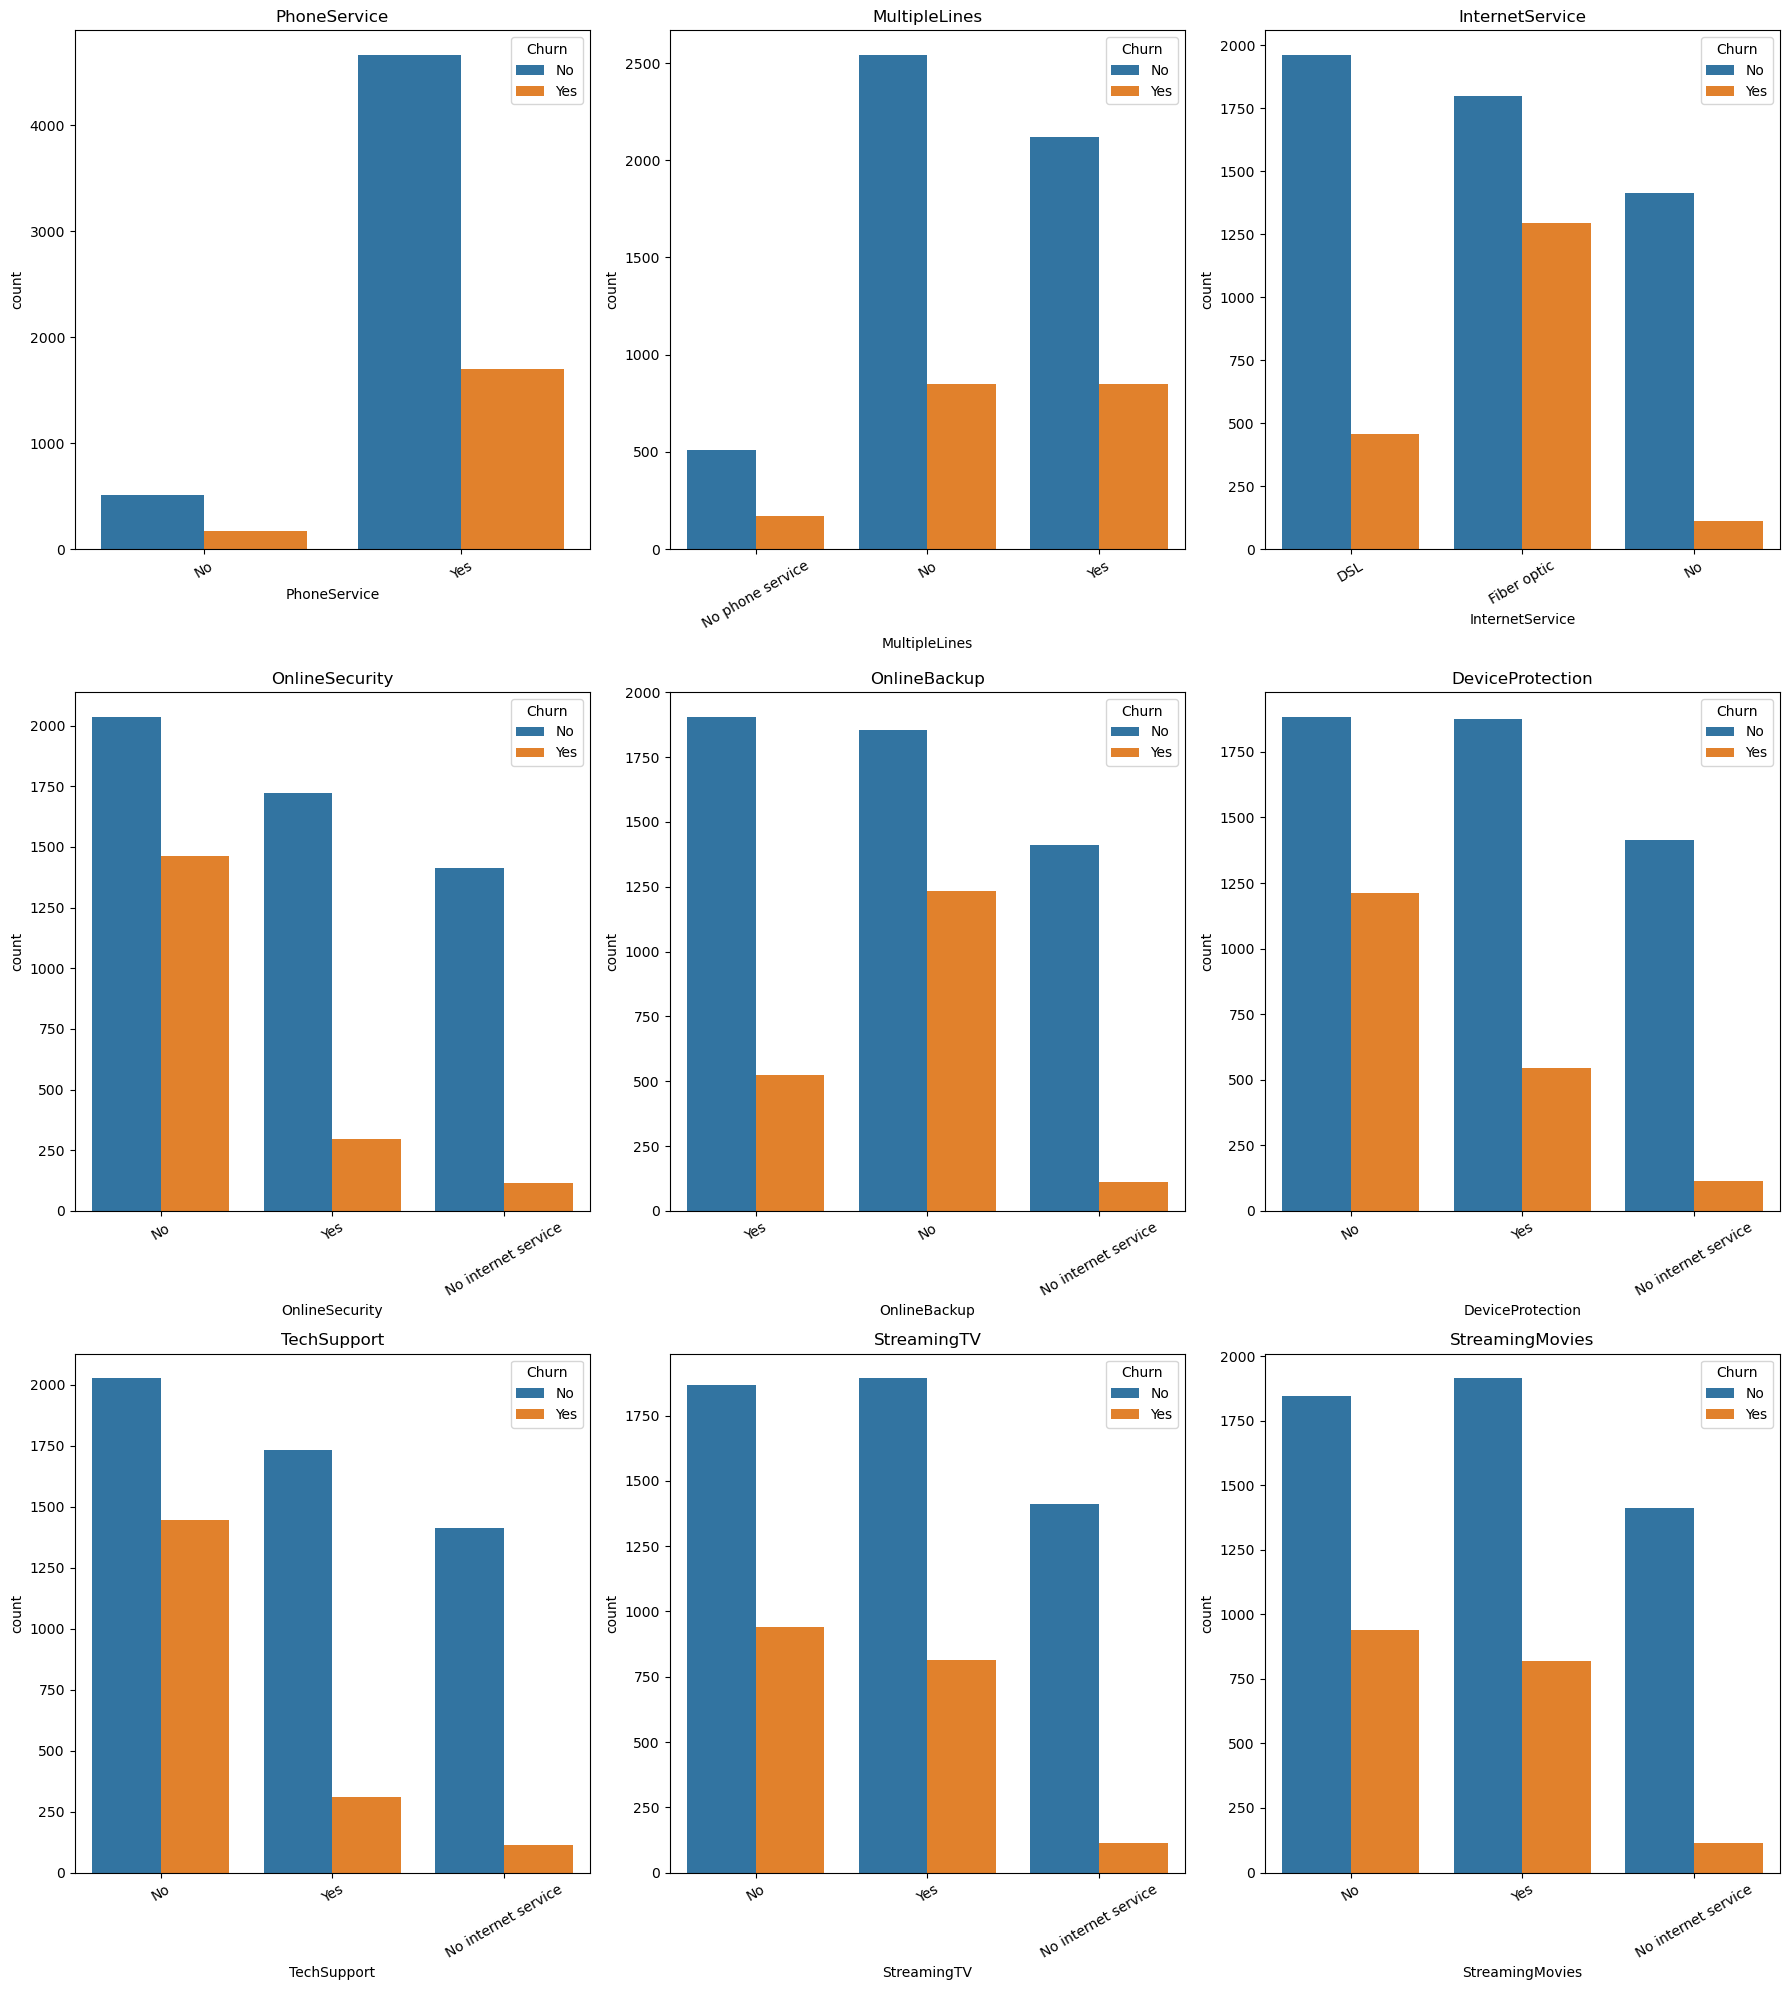

In [51]:
# your columns
cols = ['PhoneService', 'MultipleLines', 'InternetService',
        'OnlineSecurity', 'OnlineBackup', 'DeviceProtection',
        'TechSupport', 'StreamingTV', 'StreamingMovies']

# set subplot grid size
rows = 3
cols_per_row = 3

plt.figure(figsize=(18, 20))

for i, col in enumerate(cols, 1):
    plt.subplot(rows, cols_per_row, i)
    sns.countplot(data=df, x=col,hue = df["Churn"])
    plt.title(col)
    plt.xticks(rotation=30)

plt.tight_layout()
plt.show()

In [ ]:
##Customers with no additional services (like OnlineSecurity, TechSupport, DeviceProtection) show a much higher churn rate compared to those who have these services.
#Users with Fiber optic internet tend to churn more than DSL users, indicating possible dissatisfaction or pricing issues.
#Having multiple lines or streaming services doesn’t strongly reduce churn, but users without them churn slightly less consistently.
#Overall, value-added support and security services play a key role in customer retention

In [ ]:
plt.figure(figsize = (4,4))
sns.countplot(x = 'PaymentMethod',data = df,hue = "Churn")
plt.title("Count of Customer by PaymentMethod")
plt.show()